[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter11_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 11: Fractal markets hypothesis and long memory

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Self-similarity: the scaling of $h$-day returns (S&P 500, BET, Bitcoin).
- The R/S statistic step by step; fractional Brownian motion (SFEfbmplot), fractional Gaussian noise (SFEfgnacf) and ARFIMA(0,d,0) (SFEarfima), simulated exactly by circulant embedding.
- Estimators: R/S, Lo's modified R/S, DFA, GPH; Monte Carlo bands; size and power of the R/S tests.
- Spurious long memory: the Nile and its 1898 break, mean shifts, GARCH volatility clustering.
- Long memory in volatility on six markets; rolling Hurst exponents.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 14; Peters (1994); Hurst (1951); Lo (1991); Peng et al. (1994); Geweke and Porter-Hudak (1983); Weron (2002).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; S&P 500, DAX and BET since 2000, Bitcoin since 2014, Banca Transilvania and OMV Petrom since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Hurst exponent $H$: $H = 0.5$ no memory, $H > 0.5$ persistence, $H < 0.5$ anti-persistence; memory parameter $d = H - 0.5$.
- R/S: $(R/S)_n$ = range of the cumulative deviations divided by the standard deviation, averaged over blocks of size $n$; $\hat H$ = slope of $\log (R/S)_n$ on $\log n$.
- DFA: slope of $\log F(n)$ on $\log n$, $F(n)$ the root mean square deviation of the profile from local straight lines.
- GPH: OLS slope $\hat d$ of $\log I(\lambda_j)$ on $-\log(4\sin^2(\lambda_j/2))$, $j \le m = [T^{0.5}]$.
- Lo's test: $V(q) = R/(\sqrt{N}\hat\sigma(q))$; short memory rejected at 5% outside $[0.809, 1.862]$.

In [5]:
from scipy import special
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'tlv', 'snp']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
SEED = 2026
NMIN = 10
WINDOW = 1000
STEP = 21
MC_REPS = 500
LO_CRIT = (0.809, 1.862)
GPH_POWER = 0.5
RS_EXAMPLE = [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7]
NILE_BREAK = 1898
H_LIST = [1, 2, 5, 10, 20, 50, 100, 250]
MC_N = [250, 500, 1000, 2500, 5000]
PHIS = [0.0, 0.1, 0.2, 0.3, 0.5]
HS_POWER = [0.5, 0.6, 0.7, 0.8]
DELTAS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
PERS = [0.8, 0.9, 0.95, 0.98, 0.99]


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def block_sizes(N, nmin=NMIN, nmax=None, num=20):
    """Block sizes for R/S and DFA: about `num` values spaced evenly on a log scale between nmin and N/4."""
    nmax = nmax or N // 4
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(nmax), num)).astype(int))


def rs_block(x):
    """R/S of one block: range of the cumulative deviations from the mean, divided by the standard deviation."""
    x = np.asarray(x, float)
    y = np.cumsum(x - x.mean())
    return (y.max() - y.min()) / x.std()


def rs_curve(x, sizes=None):
    """Average R/S over the non-overlapping blocks of each size n (Hurst 1951; Mandelbrot and Wallis 1969)."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    out = []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R = Y.max(axis=1) - Y.min(axis=1)
        S = X.std(axis=1)
        ok = S > 0
        out.append(np.mean(R[ok] / S[ok]))
    return sizes, np.array(out)


def hurst_rs(x, sizes=None):
    """Hurst exponent: slope of log(R/S)_n on log n."""
    n, rs = rs_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(rs), 1)[0])


def dfa_curve(x, sizes=None):
    """DFA-1 (Peng et al. 1994): profile Y = cumsum(x - mean); in each block of size n a straight line is fitted
    to Y; F(n) is the root mean square of the deviations from the lines."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    Y = np.cumsum(x - x.mean())
    F = []
    for n in sizes:
        m = len(Y) // n
        B = Y[:m * n].reshape(m, n)
        t = np.arange(n) - (n - 1) / 2
        b = (B - B.mean(axis=1, keepdims=True)) @ t / (t @ t)
        resid = B - B.mean(axis=1, keepdims=True) - np.outer(b, t)
        F.append(np.sqrt(np.mean(resid ** 2)))
    return sizes, np.array(F)


def hurst_dfa(x, sizes=None):
    """DFA exponent: slope of log F(n) on log n (equal to H for fractional Gaussian noise)."""
    n, F = dfa_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(F), 1)[0])


def periodogram(x):
    """I(lambda_j) = |sum_t x_t exp(-i lambda_j t)|^2 / (2 pi T) at the Fourier frequencies lambda_j = 2 pi j / T."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    return 2 * np.pi * j / T, I[1:T // 2 + 1]


def gph(x, power=GPH_POWER):
    """GPH estimator of d (Geweke and Porter-Hudak 1983; FHH 14.5.2): OLS slope of log I(lambda_j) on
    -log(4 sin^2(lambda_j / 2)), j = 1, ..., m = [T^power]; asymptotic standard error pi / sqrt(24 m)."""
    lam, I = periodogram(x)
    m = int(np.floor(len(x) ** power))
    X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
    y = np.log(I[:m])
    d = float(np.polyfit(X, y, 1)[0])
    return {'d': d, 'se': float(np.pi / np.sqrt(24 * m)), 'm': m, 'H': d + 0.5}


def lo_test(x, q=None):
    """Lo's (1991) modified R/S: V(q) = R / (sqrt(N) sigma(q)), sigma^2(q) the Newey-West variance with Bartlett
    weights 1 - j/(q+1); q = 0 gives the classical statistic. Default q: Andrews (1991) rule used by Lo,
    q = [(3N/2)^(1/3) (2 rho / (1 - rho^2))^(2/3)], rho the first-order autocorrelation.
    Short memory is rejected at 5% if V is outside [0.809, 1.862]."""
    x = np.asarray(x, float)
    N = len(x)
    xc = x - x.mean()
    Y = np.cumsum(xc)
    R = Y.max() - Y.min()
    g0 = xc @ xc / N
    rho = (xc[1:] @ xc[:-1] / N) / g0
    if q is None:
        q = int(np.floor((1.5 * N) ** (1 / 3) * (2 * abs(rho) / (1 - rho ** 2)) ** (2 / 3)))
    s2 = g0 + 2 * sum((1 - j / (q + 1)) * (xc[j:] @ xc[:-j] / N) for j in range(1, q + 1))
    V = R / np.sqrt(N * s2)
    V0 = R / np.sqrt(N * g0)
    return {'V': float(V), 'V0': float(V0), 'q': int(q), 'rho1': float(rho),
            'reject': bool(not LO_CRIT[0] <= V <= LO_CRIT[1]), 'reject0': bool(not LO_CRIT[0] <= V0 <= LO_CRIT[1])}


def acf(x, nlags):
    """Sample autocorrelations at lags 1..nlags."""
    x = np.asarray(x, float) - np.mean(x)
    g0 = x @ x
    return np.array([x[k:] @ x[:-k] / g0 for k in range(1, nlags + 1)])


def all_estimates(x):
    """R/S, DFA, GPH (d and H = d + 1/2) and Lo's test of one series."""
    g = gph(x)
    lo = lo_test(x)
    return {'n': int(len(x)), 'rs': hurst_rs(x), 'dfa': hurst_dfa(x), 'gph_d': g['d'], 'gph_se': g['se'],
            'gph_m': g['m'], 'gph_H': g['H'], 'lo_V': lo['V'], 'lo_V0': lo['V0'], 'lo_q': lo['q'],
            'lo_reject': lo['reject'], 'lo_reject0': lo['reject0']}


def fgn_acvf(n, H):
    """Autocovariances of standard fractional Gaussian noise: 0.5 (|k+1|^2H - 2|k|^2H + |k-1|^2H), k = 0..n-1."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def arfima_acf(n, d):
    """Autocorrelations of ARFIMA(0,d,0): rho_k = Gamma(1-d) Gamma(k+d) / (Gamma(d) Gamma(k+1-d)), k = 0..n-1,
    computed with the recursion rho_k = rho_{k-1} (k - 1 + d) / (k - d)."""
    r = np.ones(n)
    for k in range(1, n):
        r[k] = r[k - 1] * (k - 1 + d) / (k - d)
    return r


def arfima_var(d):
    """Variance of ARFIMA(0,d,0) with unit innovation variance: Gamma(1 - 2d) / Gamma(1 - d)^2."""
    return float(np.exp(special.gammaln(1 - 2 * d) - 2 * special.gammaln(1 - d)))


def circulant_gaussian(acvf, rng, size=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acvf[0..n-1] by circulant embedding
    (Davies and Harte); returns an array (size, n)."""
    n = len(acvf)
    c = np.concatenate([acvf, acvf[-2:0:-1]])
    M = len(c)
    lam = np.clip(np.fft.fft(c).real, 0, None)
    Z = rng.standard_normal((size, M)) + 1j * rng.standard_normal((size, M))
    W = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    return W.real[:, :n]


def sim_fgn(n, H, rng, size=1):
    return circulant_gaussian(fgn_acvf(n, H), rng, size)


def sim_arfima(n, d, rng, size=1):
    return circulant_gaussian(arfima_var(d) * arfima_acf(n, d), rng, size)


def sim_garch(n, omega, alpha, beta, rng, size=1, burn=500):
    """GARCH(1,1) with Normal innovations, `size` independent paths of length n (unconditional variance 1 if
    omega = 1 - alpha - beta)."""
    z = rng.standard_normal((size, n + burn))
    s2 = np.full(size, omega / (1 - alpha - beta))
    e = np.empty((size, n + burn))
    for t in range(n + burn):
        e[:, t] = np.sqrt(s2) * z[:, t]
        s2 = omega + alpha * e[:, t] ** 2 + beta * s2
    return e[:, burn:]


def mc_null(N, reps=MC_REPS, seed=SEED):
    """Distribution of the R/S, DFA and GPH estimates for i.i.d. Normal series of length N."""
    rng = np.random.default_rng(seed + N)
    rs, dfa, gp = [], [], []
    sizes = block_sizes(N)
    for _ in range(reps):
        x = rng.standard_normal(N)
        rs.append(hurst_rs(x, sizes))
        dfa.append(hurst_dfa(x, sizes))
        gp.append(gph(x)['H'])
    out = {}
    for k, v in [('rs', rs), ('dfa', dfa), ('gph', gp)]:
        v = np.array(v)
        out[k] = {'mean': float(v.mean()), 'sd': float(v.std()), 'q025': float(np.quantile(v, 0.025)),
                  'q975': float(np.quantile(v, 0.975))}
    return out


def rolling_hurst(x, window=WINDOW, step=STEP, est=hurst_dfa):
    """Hurst exponent on rolling windows; the value is dated at the last day of the window."""
    x = pd.Series(x)
    sizes = block_sizes(window)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(est(x.values[e - window:e], sizes))
    return pd.Series(val, index=idx)


def rs_steps(x):
    """All steps of the R/S statistic of one short block: mean, deviations, cumulative deviations, R, S, R/S."""
    x = np.asarray(x, float)
    dev = x - x.mean()
    Y = np.cumsum(dev)
    R = Y.max() - Y.min()
    S = x.std()
    return {'x': x.tolist(), 'mean': float(x.mean()), 'dev': dev.tolist(), 'Y': Y.tolist(), 'max': float(Y.max()),
            'min': float(Y.min()), 'kmax': int(np.argmax(Y)) + 1, 'kmin': int(np.argmin(Y)) + 1, 'R': float(R),
            'S': float(S), 'RS': float(R / S), 'sumsq': float(dev @ dev)}

## 1. Self-similarity: the scaling of $h$-day returns

- Standard deviation of non-overlapping $h$-day returns against $h$; the square-root-of-time rule has slope 0.5.

In [6]:
def scaling(r, hs=H_LIST):
    """Standard deviation of non-overlapping h-day sums of returns; slope of log sd(h) on log h (aggregated
    standard deviation estimator of H)."""
    x = np.asarray(r, float)
    sd = []
    for h in hs:
        m = len(x) // h
        sd.append(x[:m * h].reshape(m, h).sum(axis=1).std())
    sd = np.array(sd)
    H = float(np.polyfit(np.log10(hs), np.log10(sd), 1)[0])
    return np.array(hs), sd, H


def fig_scaling(names=('sp500', 'bet', 'btc'), save=True):
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    out = {}
    for k in names:
        hs, sd, H = scaling(returns(k))
        ax.loglog(hs, sd / sd[0], 'o-', color=COLORS[k], lw=1.4, label=f'{NAME[k]}: slope H = {H:.2f}')
        out[k] = {'H': H, 'sd1': float(sd[0]), 'sd10': float(sd[3]), 'sd250': float(sd[-1]),
                  'ratio10': float(sd[3] / sd[0]), 'ratio250': float(sd[-1] / sd[0])}
    hs = np.array(H_LIST)
    ax.loglog(hs, hs ** 0.5, color='black', ls='--', lw=1.0, label='square-root-of-time rule, slope 0.5')
    ax.set_xlabel('horizon h in days (log scale)')
    ax.set_ylabel('sd of h-day returns / sd of 1-day returns')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_scaling')
    return out

{'sp500': {'H': 0.47846718270661887,
  'sd1': 1.212939250854622,
  'sd10': 3.392079323681549,
  'sd250': 16.858372280399088,
  'ratio10': 2.796578081953842,
  'ratio250': 13.898777097468722},
 'bet': {'H': 0.5853520865135463,
  'sd1': 1.398533720593651,
  'sd10': 4.891802207909741,
  'sd250': 38.355746075448046,
  'ratio10': 3.497807836791568,
  'ratio250': 27.425685566713945},
 'btc': {'H': 0.5455613789326094,
  'sd1': 3.4847946927641185,
  'sd10': 11.165005020515673,
  'sd250': 66.26610796669068,
  'ratio10': 3.2039204615694756,
  'ratio250': 19.01578537877329}}

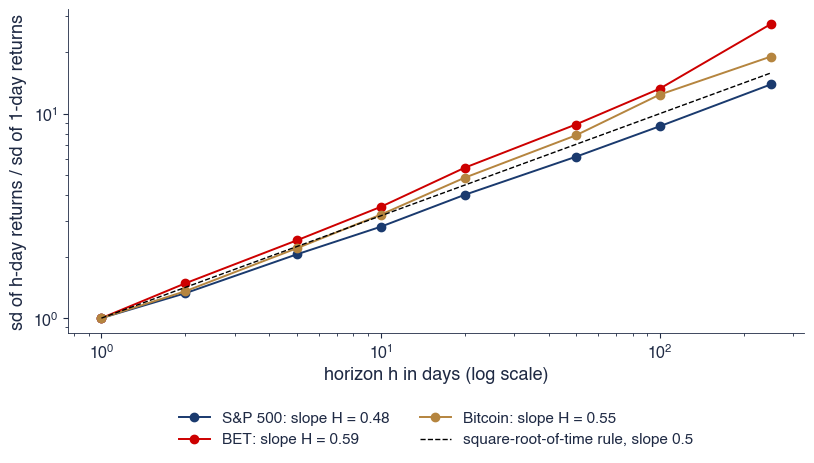

In [7]:
fig_scaling(save=False)

## 2. The R/S statistic step by step

- Eight returns: mean, cumulative deviations, range, standard deviation.

In [8]:
def fig_rs_example(x=RS_EXAMPLE, save=True):
    """The cumulative deviations Y_k of eight returns, with the range R marked."""
    s = rs_steps(x)
    k = np.arange(1, len(x) + 1)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.bar(k, s['dev'], color=st.Teal, alpha=0.6, width=0.6, label='deviation from the mean, x_k - mean')
    ax.plot(k, s['Y'], 'o-', color=st.MainBlue, lw=1.6, label='cumulative deviation Y_k')
    ax.axhline(s['max'], color=st.Forest, ls='--', lw=1.0, label=f"max Y_k = {s['max']:.3f} (k = {s['kmax']})")
    ax.axhline(s['min'], color=st.IDAred, ls='--', lw=1.0, label=f"min Y_k = {s['min']:.3f} (k = {s['kmin']})")
    ax.annotate('', xy=(len(x) + 0.45, s['max']), xytext=(len(x) + 0.45, s['min']),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
    ax.text(len(x) + 0.55, (s['max'] + s['min']) / 2, f"R = {s['R']:.3f}", color='black', va='center')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlim(0.4, len(x) + 1.4)
    ax.set_xticks(k)
    ax.set_xlabel('k')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_rs_example')
    return s

{'x': [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7],
 'mean': 0.125,
 'dev': [0.375, -0.425, 0.675, -0.325, 0.475, -0.225, 0.275, -0.825],
 'Y': [0.375,
  -0.04999999999999999,
  0.625,
  0.3,
  0.7749999999999999,
  0.5499999999999999,
  0.825,
  0.0],
 'max': 0.825,
 'min': -0.04999999999999999,
 'kmax': 7,
 'kmin': 2,
 'R': 0.875,
 'S': 0.48925964476952316,
 'RS': 1.788416456076586,
 'sumsq': 1.915}

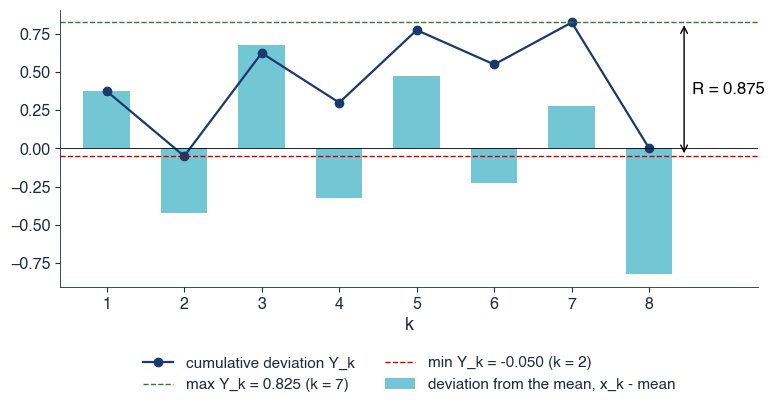

In [9]:
fig_rs_example(save=False)

## 3. Fractional Brownian motion and fractional Gaussian noise

- Exact simulation of fGn by circulant embedding; fBm paths for $H = 0.3, 0.5, 0.7$ (SFEfbmplot).
- Sample and theoretical ACF for $H = 0.2$ and $0.8$ (SFEfgnacf); hyperbolic against exponential decay.

In [10]:
def fig_fbm_paths(n=1000, Hs=(0.3, 0.5, 0.7), save=True):
    """Fractional Brownian motion paths for three Hurst exponents (as in SFEfbmplot); the same random numbers."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    out = {}
    for H, c in zip(Hs, [st.IDAred, st.MainBlue, st.Forest]):
        rng = np.random.default_rng(SEED)
        x = sim_fgn(n, H, rng)[0]
        b = np.concatenate([[0], np.cumsum(x)])
        lab = {0.5: 'H = 0.5: Brownian motion'}.get(H, f'H = {H}: ' + ('anti-persistent' if H < 0.5 else 'persistent'))
        axes[0].plot(np.arange(n + 1), b, color=c, lw=1.0, label=lab)
        axes[1].plot(np.arange(150), x[:150], color=c, lw=0.9, label='_')
        out[str(H)] = {'acf1': float(acf(x, 1)[0]), 'acf1_th': float(2 ** (2 * H - 1) - 1), 'range': float(b.max() - b.min())}
    axes[0].set_title('fractional Brownian motion B_H(t)')
    axes[1].set_title('its increments (fractional Gaussian noise), first 150')
    for ax in axes:
        ax.set_xlabel('time t')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_fbm_paths')
    return out


def fig_fgn_acf(n=5000, nlags=50, save=True):
    """ACF of fractional Gaussian noise for H = 0.2 and 0.8 (as in SFEfgnacf): sample and theoretical; right panel:
    hyperbolic decay of fGn (H = 0.8) against the exponential decay of an AR(1) with the same lag-1 autocorrelation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    k = np.arange(1, nlags + 1)
    out = {}
    for H, c in [(0.8, st.MainBlue), (0.2, st.IDAred)]:
        rng = np.random.default_rng(SEED + int(10 * H))
        x = sim_fgn(n, H, rng)[0]
        th = fgn_acvf(nlags + 1, H)[1:]
        axes[0].plot(k, acf(x, nlags), 'o', ms=3.5, color=c, label=f'H = {H}: sample ACF (n = {n})')
        axes[0].plot(k, th, '-', lw=1.4, color=c, label=f'H = {H}: theoretical ACF')
        out[str(H)] = {'rho1': float(th[0]), 'rho10': float(th[9]), 'rho50': float(th[49])}
    axes[0].axhline(0, color='black', lw=0.6)
    axes[0].set_xlabel('lag k')
    axes[0].set_ylabel('autocorrelation')
    H = 0.8
    kk = np.arange(1, 1001)
    rf = fgn_acvf(1001, H)[1:]
    phi = rf[0]
    axes[1].loglog(kk, rf, color=st.MainBlue, lw=1.6, label=f'fGn, H = {H}: hyperbolic decay, k^(2H-2)')
    axes[1].loglog(kk, phi ** kk, color=st.Orange, lw=1.6, label=f'AR(1), phi = {phi:.3f}: exponential decay')
    axes[1].set_ylim(1e-4, 1)
    axes[1].set_xlabel('lag k (log scale)')
    axes[1].set_ylabel('autocorrelation (log scale)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_fgn_acf')
    out['ar1_phi'] = float(phi)
    out['ar1_rho10'] = float(phi ** 10)
    out['ar1_rho50'] = float(phi ** 50)
    out['fgn_rho100'] = float(rf[99])
    out['ar1_rho100'] = float(phi ** 100)
    return out

{'0.3': {'acf1': -0.2326279009381103,
  'acf1_th': -0.242141716744801,
  'range': 15.276015337401724},
 '0.5': {'acf1': 0.012819580734563804,
  'acf1_th': 0.0,
  'range': 35.4934248440953},
 '0.7': {'acf1': 0.31605443535403394,
  'acf1_th': 0.3195079107728942,
  'range': 96.42505462929822}}

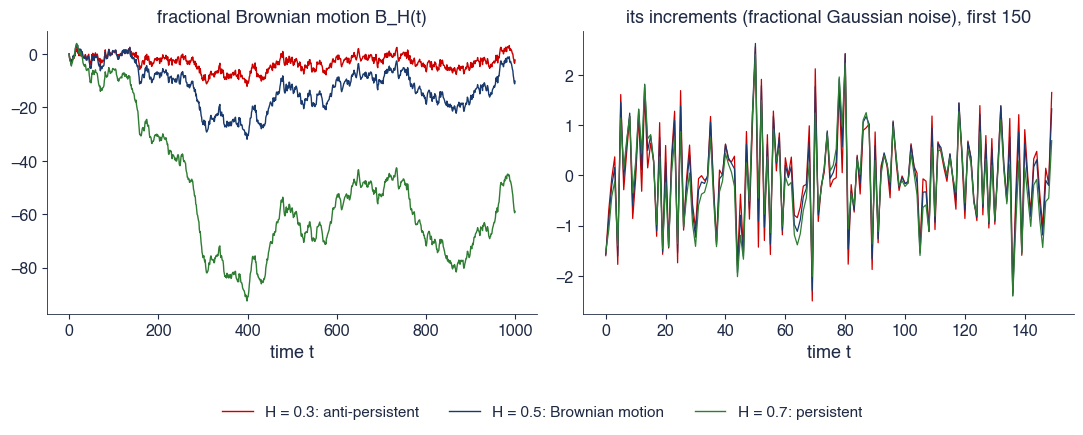

In [11]:
fig_fbm_paths(save=False)

{'0.8': {'rho1': 0.5157165665103982,
  'rho10': 0.19118086146520952,
  'rho50': 0.10038327103879396},
 '0.2': {'rho1': -0.3402460446135529,
  'rho10': -0.003024771229797274,
  'rho50': -0.0002295564343905987},
 'ar1_phi': 0.5157165665103982,
 'ar1_rho10': 0.0013307939749235271,
 'ar1_rho50': 4.174016195391455e-15,
 'fgn_rho100': 0.07607522826401691,
 'ar1_rho100': 1.742241119939015e-29}

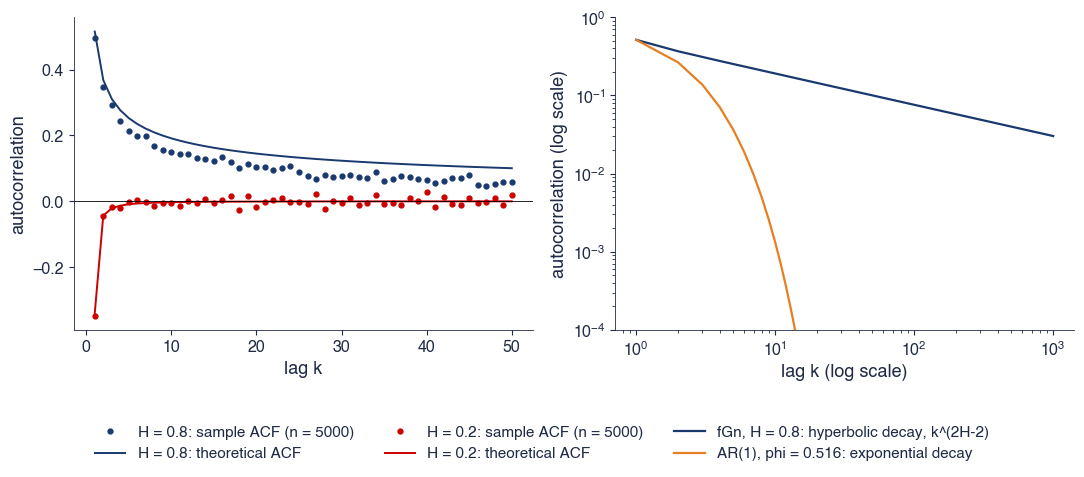

In [12]:
fig_fgn_acf(save=False)

## 4. ARFIMA(0,d,0)

- Paths and ACF for $d = 0.4$ and $d = -0.4$ (SFEarfima).

In [13]:
def fig_arfima(n=1000, ds=(0.4, -0.4), nlags=50, save=True):
    """ARFIMA(0,d,0) paths and ACF for d = 0.4 and d = -0.4 (as in SFEarfima), Gaussian white noise N(0, 1)."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 5.4), gridspec_kw={'width_ratios': [2.2, 1]})
    k = np.arange(1, nlags + 1)
    out = {}
    for row, (d, c) in enumerate(zip(ds, [st.MainBlue, st.IDAred])):
        rng = np.random.default_rng(SEED + 7 + row)
        x = sim_arfima(n, d, rng)[0]
        axes[row, 0].plot(np.arange(n), x, color=c, lw=0.7, label=f'ARFIMA(0,d,0), d = {d}: path')
        axes[row, 0].set_ylabel('x(t)')
        th = arfima_acf(nlags + 1, d)[1:]
        xl = sim_arfima(20000, d, np.random.default_rng(SEED + 17 + row))[0]
        axes[row, 1].bar(k, acf(xl, nlags), color=c, alpha=0.55, width=0.8, label=f'd = {d}: sample ACF (n = 20000)')
        axes[row, 1].plot(k, th, color='black', lw=1.2, label='theoretical ACF' if row == 0 else '_')
        axes[row, 1].axhline(0, color='black', lw=0.6)
        out[str(d)] = {'rho1': float(th[0]), 'rho2': float(th[1]), 'rho10': float(th[9]), 'rho50': float(th[49]),
                       'sd': float(x.std()), 'var_th': arfima_var(d)}
    axes[1, 0].set_xlabel('time t')
    axes[1, 1].set_xlabel('lag k')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_arfima')
    return out

{'0.4': {'rho1': 0.6666666666666667,
  'rho2': 0.5833333333333333,
  'rho10': 0.42356815660524905,
  'rho50': 0.30701712214279436,
  'sd': 1.3667219615958026,
  'var_th': 2.0700983252962857},
 '-0.4': {'rho1': -0.28571428571428575,
  'rho2': -0.07142857142857144,
  'rho10': -0.0037834857922467427,
  'rho50': -0.00020847077132197319,
  'sd': 1.0936915501898756,
  'var_th': 1.183104546842922}}

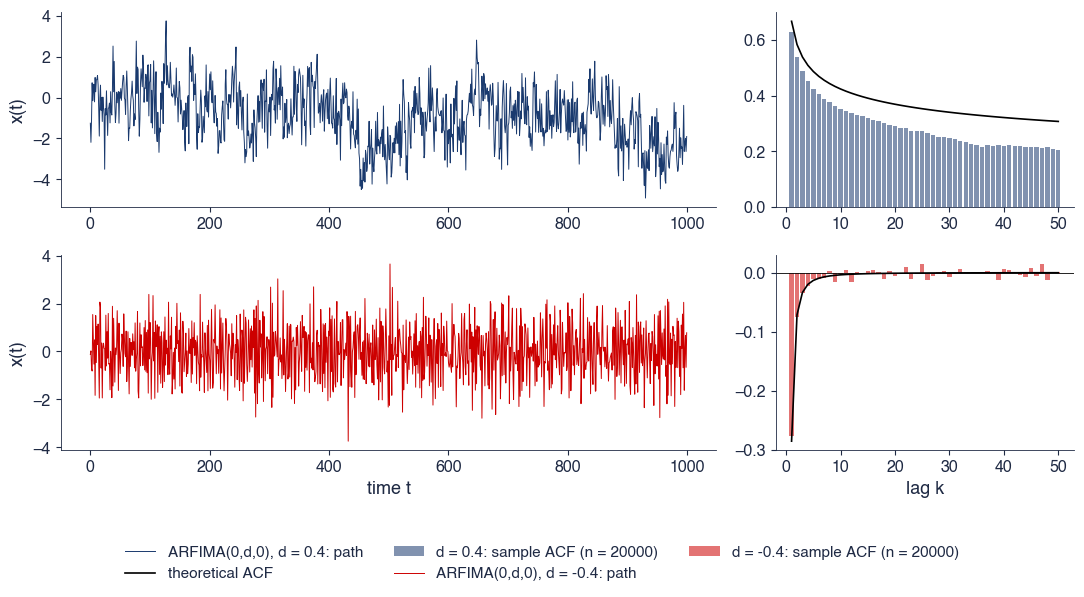

In [14]:
fig_arfima(save=False)

## 5. Estimators on the S&P 500: R/S, DFA, GPH and Lo's test

- Log-log plots for returns and absolute returns, with the mean curve of i.i.d. Normal series.

In [15]:
def fig_rs_dfa(k='sp500', save=True, reps=MC_REPS):
    """R/S and DFA log-log plots of the returns and absolute returns, with the i.i.d. Monte Carlo mean."""
    r = returns(k)
    x, a = r.values, np.abs(r.values)
    N = len(x)
    sizes = block_sizes(N)
    rng = np.random.default_rng(SEED + 5)
    sims = rng.standard_normal((min(reps, 200), N))
    rs0 = np.mean([rs_curve(v, sizes)[1] for v in sims], axis=0)
    F0 = np.mean([dfa_curve(v, sizes)[1] for v in sims], axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    out = {}
    for ax, curve, base, lab in [(axes[0], rs_curve, rs0, '(R/S)_n'), (axes[1], dfa_curve, F0, 'F(n) / F(10)')]:
        for y, c, m, nm in [(x, COLORS[k], 'o', 'returns r'), (a, st.Purple, 's', 'absolute returns |r|')]:
            n, v = curve(y, sizes)
            if lab.startswith('F'):
                v = v / v[0]
            sl = float(np.polyfit(np.log10(n), np.log10(v), 1)[0])
            meth = 'R/S' if lab.startswith('(') else 'DFA'
            ax.loglog(n, v, m, ms=4, color=c, label=f'{meth}, {nm}: slope {sl:.2f}')
            out[f"{'rs' if lab.startswith('(') else 'dfa'}_{'r' if nm.startswith('ret') else 'abs'}"] = sl
        b = base / base[0] if lab.startswith('F') else base
        ax.loglog(sizes, b, color='black', ls='--', lw=1.0, label='i.i.d. Normal (Monte Carlo mean)')
        ax.set_xlabel('block size n (log scale)')
        ax.set_ylabel(lab + ' (log scale)')
    axes[0].set_title('R/S analysis')
    axes[1].set_title('DFA')
    out['rs_iid'] = float(np.polyfit(np.log10(sizes), np.log10(rs0), 1)[0])
    out['dfa_iid'] = float(np.polyfit(np.log10(sizes), np.log10(F0), 1)[0])
    out['rs_n10'] = float(rs0[0])
    out['nmin'] = int(sizes[0])
    out['nmax'] = int(sizes[-1])
    out['nsizes'] = int(len(sizes))
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_rs_dfa')
    return out


def fig_gph(k='sp500', save=True):
    """The GPH log-periodogram regression for the returns and absolute returns."""
    r = returns(k)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=False)
    out = {}
    for ax, y, c, nm in [(axes[0], r.values, COLORS[k], 'returns r'), (axes[1], np.abs(r.values), st.Purple, 'absolute returns |r|')]:
        lam, I = periodogram(y)
        g = gph(y)
        m = g['m']
        X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
        ax.plot(X, np.log(I[:m]), 'o', ms=3.5, color=c, label=f'{nm}: log periodogram, m = {m} frequencies')
        b = np.polyfit(X, np.log(I[:m]), 1)
        xx = np.linspace(X.min(), X.max(), 50)
        ax.plot(xx, np.polyval(b, xx), color='black', lw=1.2, label='_')
        ax.set_title(f"{nm}: slope d = {g['d']:.2f} (SE {g['se']:.2f})")
        ax.set_xlabel('-log(4 sin^2(lambda_j / 2))')
        ax.set_ylabel('log I(lambda_j)')
        out['r' if nm.startswith('ret') else 'abs'] = g
    axes[0].plot([], [], color='black', lw=1.2, label='OLS line: slope = d')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_gph')
    return out

{'rs_r': 0.5304720271599298,
 'rs_abs': 0.8613572566975962,
 'dfa_r': 0.48832665957545135,
 'dfa_abs': 0.9533882354987302,
 'rs_iid': 0.5461183381818197,
 'dfa_iid': 0.5009225207504032,
 'rs_n10': 3.0201088346806437,
 'nmin': 10,
 'nmax': 1678,
 'nsizes': 20}

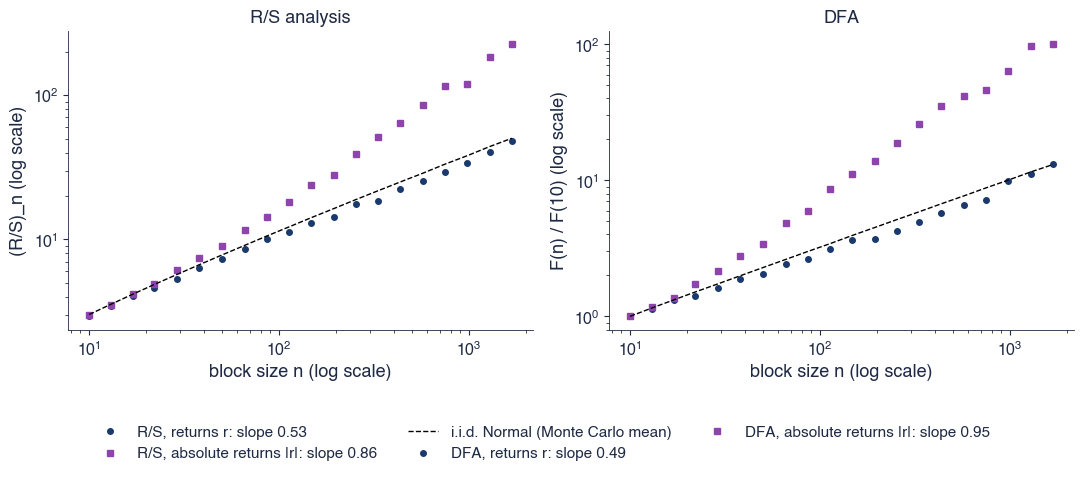

In [16]:
fig_rs_dfa(save=False)

{'r': {'d': 0.0362126399565002,
  'se': 0.07125276834232579,
  'm': 81,
  'H': 0.5362126399565001},
 'abs': {'d': 0.46962997910953785,
  'se': 0.07125276834232579,
  'm': 81,
  'H': 0.9696299791095379}}

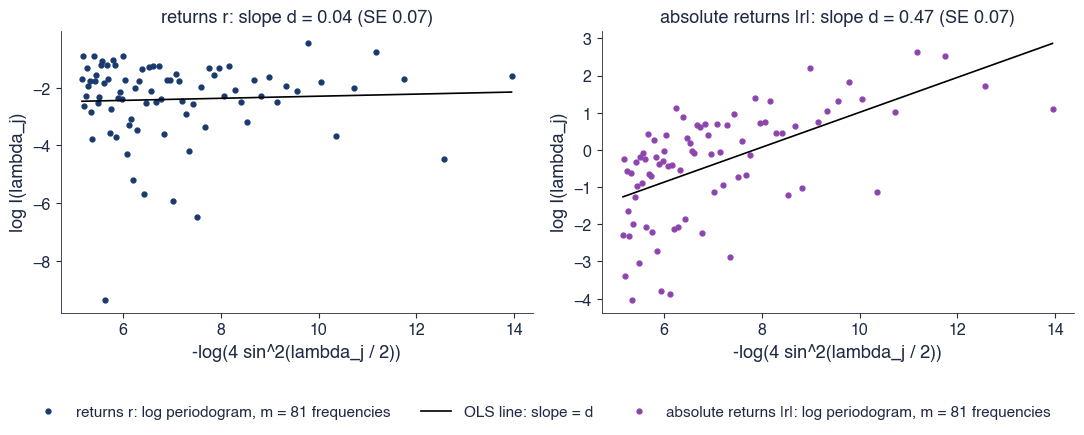

In [17]:
fig_gph(save=False)

In [18]:
r = returns('sp500')
pd.DataFrame({'returns': all_estimates(r.values), '|returns|': all_estimates(np.abs(r.values))}).T

,n,rs,dfa,gph_d,gph_se,gph_m,gph_H,lo_V,lo_V0,lo_q,lo_reject,lo_reject0
returns,6714,0.530472,0.488327,0.036213,0.071253,81,0.536213,1.559366,1.378687,7,False,False
|returns|,6714,0.861357,0.953388,0.46963,0.071253,81,0.96963,2.663501,6.37292,15,True,True


## 6. Monte Carlo: small-sample bias, bands, size and power of the R/S tests

- 500 i.i.d. Normal series for each $N$ (Weron, 2002).
- Rejection rates of the classical and modified R/S tests under AR(1) and fractional Gaussian noise.

In [19]:
def fig_mc_bias(Ns=MC_N, reps=MC_REPS, save=True):
    """Mean and 95% Monte Carlo band of the three estimators under i.i.d. Normal returns, against N (Weron 2002)."""
    res = {N: mc_null(N, reps) for N in Ns}
    fig, ax = plt.subplots(figsize=(10, 4.2))
    off = {'rs': -0.06, 'dfa': 0.0, 'gph': 0.06}
    for k, c, lab in [('rs', st.IDAred, 'R/S'), ('dfa', st.MainBlue, 'DFA'), ('gph', st.Forest, 'GPH, H = d + 0.5')]:
        x = np.log10(Ns) + off[k]
        m = np.array([res[N][k]['mean'] for N in Ns])
        lo = np.array([res[N][k]['q025'] for N in Ns])
        hi = np.array([res[N][k]['q975'] for N in Ns])
        ax.errorbar(x, m, yerr=[m - lo, hi - m], fmt='o', color=c, capsize=4, lw=1.4, label=f'{lab}: mean and 95% band')
    ax.axhline(0.5, color='black', ls='--', lw=1.0, label='true value H = 0.5')
    ax.set_xticks(np.log10(Ns))
    ax.set_xticklabels([str(N) for N in Ns])
    ax.set_xlabel('sample size N (log scale)')
    ax.set_ylabel('estimated H')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_mc_bias')
    return {str(N): v for N, v in res.items()}


def lo_rejections(N=1000, reps=MC_REPS, save=True):
    """Rejection rates (5%) of the classical (q = 0) and modified (Andrews q) R/S tests under AR(1) short memory and
    under fractional Gaussian noise (long memory)."""
    rng = np.random.default_rng(SEED + 11)
    ar = {}
    for phi in PHIS:
        e = rng.standard_normal((reps, N + 200))
        x = np.empty_like(e)
        x[:, 0] = e[:, 0]
        for t in range(1, N + 200):
            x[:, t] = phi * x[:, t - 1] + e[:, t]
        x = x[:, 200:]
        t = [lo_test(v) for v in x]
        ar[str(phi)] = {'classical': float(np.mean([a['reject0'] for a in t])), 'modified': float(np.mean([a['reject'] for a in t])),
                        'q_mean': float(np.mean([a['q'] for a in t]))}
    fg = {}
    for H in HS_POWER:
        X = sim_fgn(N, H, rng, size=reps)
        t = [lo_test(v) for v in X]
        fg[str(H)] = {'classical': float(np.mean([a['reject0'] for a in t])), 'modified': float(np.mean([a['reject'] for a in t])),
                      'q_mean': float(np.mean([a['q'] for a in t]))}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
    w = 0.35
    for ax, d, xs, xl in [(axes[0], ar, PHIS, 'AR(1) coefficient phi (short memory: H0 true)'),
                          (axes[1], fg, HS_POWER, 'Hurst exponent H of fGn (long memory if H > 0.5)')]:
        i = np.arange(len(xs))
        ax.bar(i - w / 2, [d[str(v)]['classical'] for v in xs], w, color=st.IDAred, label='classical R/S test (q = 0)')
        ax.bar(i + w / 2, [d[str(v)]['modified'] for v in xs], w, color=st.MainBlue, label="Lo's modified R/S test (Andrews q)")
        ax.axhline(0.05, color='black', ls='--', lw=1.0, label='nominal level 5%')
        ax.set_xticks(i)
        ax.set_xticklabels([str(v) for v in xs])
        ax.set_xlabel(xl)
    axes[0].set_ylabel('share of rejections of short memory')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_lo_test')
    return {'N': N, 'ar': ar, 'fgn': fg}

mean     sd   q025   q975
250  rs   0.588  0.062  0.465  0.701
     dfa  0.505  0.083  0.347  0.663
     gph  0.507  0.225  0.012  0.899
500  rs   0.573  0.044  0.488  0.657
     dfa  0.498  0.060  0.381  0.622
     gph  0.495  0.172  0.124  0.793
1000 rs   0.562  0.033  0.503  0.626
     dfa  0.497  0.043  0.418  0.581
     gph  0.498  0.136  0.213  0.739
2500 rs   0.554  0.023  0.511  0.597
     dfa  0.499  0.030  0.444  0.557
     gph  0.501  0.106  0.278  0.690
5000 rs   0.547  0.018  0.510  0.581
     dfa  0.499  0.025  0.450  0.545
     gph  0.501  0.086  0.328  0.652

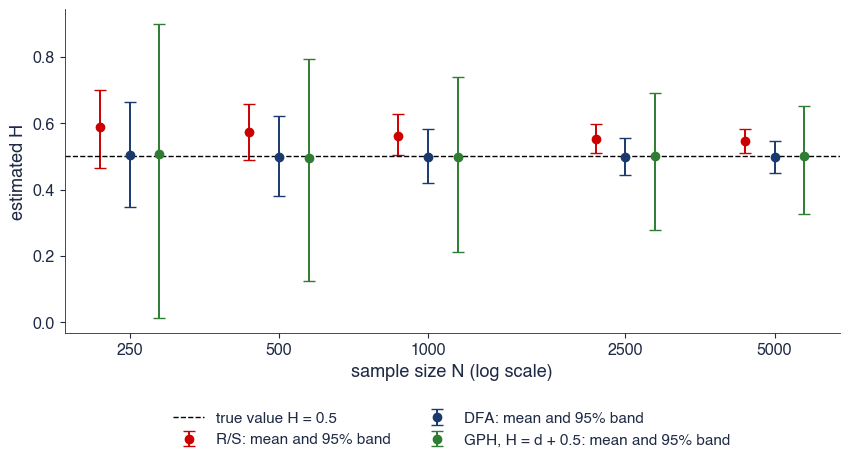

In [20]:
mc = fig_mc_bias(save=False)
pd.DataFrame({(N, k): v for N, d in mc.items() for k, v in d.items()}).T.round(3)

(     classical  modified  q_mean
 0.0      0.052     0.050   1.006
 0.1      0.080     0.050   3.408
 0.2      0.136     0.046   5.840
 0.3      0.242     0.038   8.150
 0.5      0.604     0.050  13.308,
      classical  modified  q_mean
 0.5      0.072     0.066   0.936
 0.6      0.440     0.190   4.512
 0.7      0.910     0.364   8.280
 0.8      0.998     0.504  12.786)

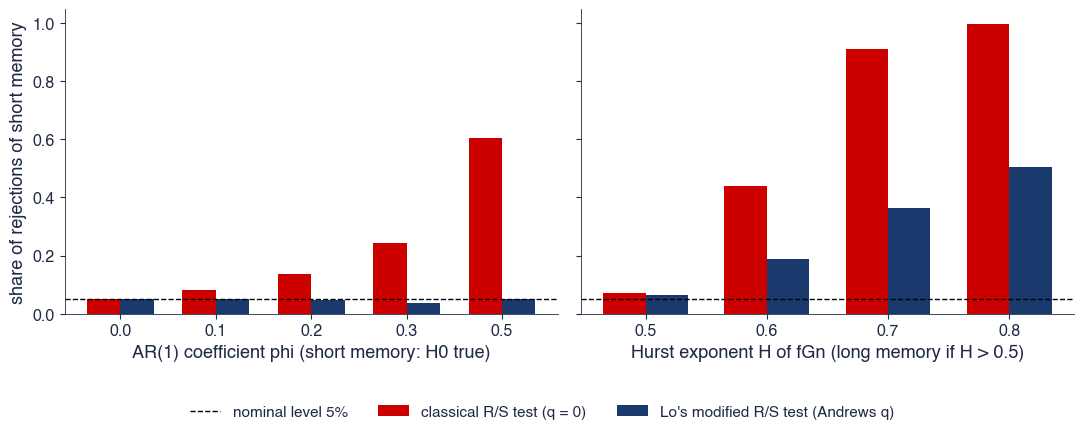

In [21]:
lo = lo_rejections(save=False)
pd.DataFrame(lo['ar']).T, pd.DataFrame(lo['fgn']).T

## 7. Spurious long memory

- The Nile at Aswan, 1871–1970 (Cobb, 1978): R/S of the raw series and after removing the two regime means.
- Simulations: a mean shift in i.i.d. noise; absolute returns of GARCH(1,1), a short-memory model.

In [22]:
def nile():
    """Annual flow of the Nile at Aswan, 1871-1970, in 10^8 cubic metres (Cobb 1978; statsmodels dataset)."""
    import statsmodels.api as sm
    d = sm.datasets.nile.load_pandas().data
    return pd.Series(d['volume'].values, index=d['year'].astype(int).values, name='Nile flow')


def fig_nile(save=True, reps=MC_REPS):
    """The Nile flow with the two regime means, and the R/S plot of the raw and of the break-adjusted series."""
    y = nile()
    N = len(y)
    sizes = block_sizes(N, nmin=6, nmax=N // 2, num=10)
    pre, post = y.loc[:NILE_BREAK], y.loc[NILE_BREAK + 1:]
    adj = pd.concat([pre - pre.mean(), post - post.mean()])
    rng = np.random.default_rng(SEED + 3)
    null = np.array([hurst_rs(rng.standard_normal(N), sizes) for _ in range(reps)])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(y.index, y.values, color=st.MainBlue, lw=1.2, label='annual flow at Aswan (10^8 m^3)')
    axes[0].hlines(pre.mean(), pre.index[0], pre.index[-1], color=st.IDAred, lw=2, label=f'mean 1871-{NILE_BREAK}: {pre.mean():.0f}')
    axes[0].hlines(post.mean(), post.index[0], post.index[-1], color=st.Forest, lw=2, label=f'mean {NILE_BREAK + 1}-1970: {post.mean():.0f}')
    axes[0].set_xlabel('year')
    n1, rs1 = rs_curve(y.values, sizes)
    n2, rs2 = rs_curve(adj.values, sizes)
    H1 = float(np.polyfit(np.log10(n1), np.log10(rs1), 1)[0])
    H2 = float(np.polyfit(np.log10(n2), np.log10(rs2), 1)[0])
    axes[1].loglog(n1, rs1, 'o-', color=st.MainBlue, lw=1.2, label=f'raw series: H = {H1:.2f}')
    axes[1].loglog(n2, rs2, 's-', color=st.Orange, lw=1.2, label=f'regime means removed: H = {H2:.2f}')
    axes[1].loglog(n1, n1 ** 0.5 * rs1[0] / n1[0] ** 0.5, color='black', ls='--', lw=0.9, label='slope 0.5')
    axes[1].set_xlabel('block size n')
    axes[1].set_ylabel('(R/S)_n')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_nile')
    return {'N': N, 'H_raw': H1, 'H_adj': H2, 'dfa_raw': hurst_dfa(y.values, sizes), 'dfa_adj': hurst_dfa(adj.values, sizes),
            'mean_pre': float(pre.mean()), 'mean_post': float(post.mean()), 'q025': float(np.quantile(null, 0.025)),
            'q975': float(np.quantile(null, 0.975)), 'null_mean': float(null.mean()), 'first': int(y.index[0]), 'last': int(y.index[-1])}


def spurious(N=2000, reps=300, save=True):
    """Spurious long memory: (a) i.i.d. N(0,1) with a mean shift of delta at N/2; (b) absolute returns of GARCH(1,1)
    (alpha = 0.10, unconditional variance 1), a short-memory model, for several persistences alpha + beta."""
    rng = np.random.default_rng(SEED + 21)
    sizes = block_sizes(N)
    br = {}
    for dl in DELTAS:
        X = rng.standard_normal((reps, N))
        X[:, N // 2:] += dl
        br[str(dl)] = {'rs': float(np.mean([hurst_rs(v, sizes) for v in X])), 'dfa': float(np.mean([hurst_dfa(v, sizes) for v in X])),
                       'gph': float(np.mean([gph(v)['H'] for v in X]))}
    ga = {}
    for p in PERS:
        E = sim_garch(N, 1 - p, 0.10, p - 0.10, rng, size=reps)
        A = np.abs(E)
        ga[str(p)] = {'abs_dfa': float(np.mean([hurst_dfa(v, sizes) for v in A])), 'abs_gph': float(np.mean([gph(v)['H'] for v in A])),
                      'ret_dfa': float(np.mean([hurst_dfa(v, sizes) for v in E])),
                      'acf50': float(np.mean([acf(v, 50)[-1] for v in A])), 'acf50_th_factor': float(p ** 49)}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for k, c, lab in [('rs', st.IDAred, 'R/S'), ('dfa', st.MainBlue, 'DFA'), ('gph', st.Forest, 'GPH, d + 0.5')]:
        axes[0].plot(DELTAS, [br[str(d)][k] for d in DELTAS], 'o-', color=c, lw=1.4, label=f'{lab}: mean estimate')
    axes[0].set_xlabel('mean shift at N/2 (in standard deviations)')
    axes[0].set_ylabel('estimated H')
    axes[1].plot(PERS, [ga[str(p)]['abs_dfa'] for p in PERS], 's-', color=st.Purple, lw=1.4, label='DFA of |r| (GARCH)')
    axes[1].plot(PERS, [ga[str(p)]['abs_gph'] for p in PERS], 'd-', color=st.Orange, lw=1.4, label='GPH of |r| (GARCH), d + 0.5')
    axes[1].plot(PERS, [ga[str(p)]['ret_dfa'] for p in PERS], '^-', color=st.Teal, lw=1.4, label='DFA of r (GARCH)')
    axes[1].set_xlabel('GARCH persistence alpha + beta (short memory)')
    for ax in axes:
        ax.axhline(0.5, color='black', ls='--', lw=1.0, label='H = 0.5 (no long memory)' if ax is axes[0] else '_')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_spurious')
    return {'N': N, 'reps': reps, 'break': br, 'garch': ga}

{'N': 100,
 'H_raw': 0.7830595549503171,
 'H_adj': 0.6331528372301882,
 'dfa_raw': 0.8383392524140991,
 'dfa_adj': 0.49530014214580653,
 'mean_pre': 1097.75,
 'mean_post': 849.9722222222222,
 'q025': 0.45158300726421213,
 'q975': 0.749892807927929,
 'null_mean': 0.5968237094877286,
 'first': 1871,
 'last': 1970}

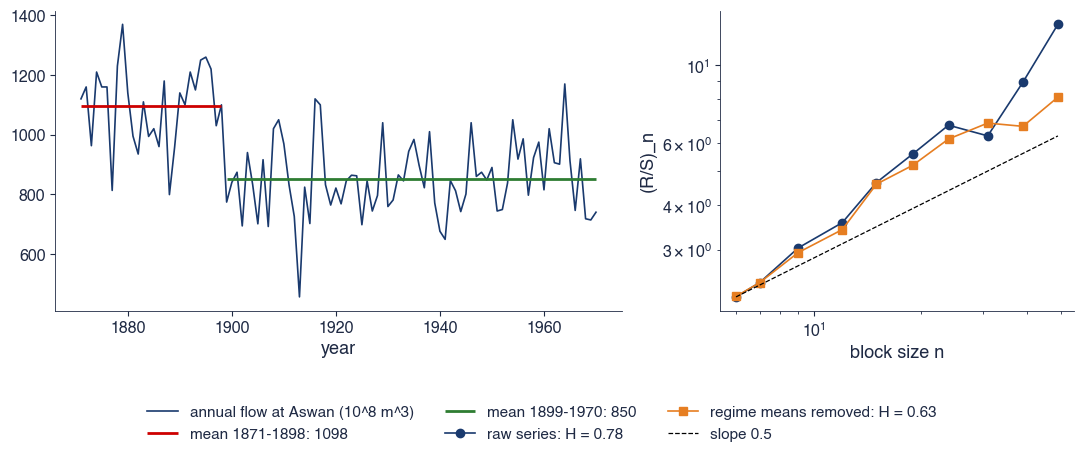

In [23]:
fig_nile(save=False)

(            rs       dfa       gph
 0.0   0.555415  0.499904  0.498941
 0.1   0.554786  0.498362  0.552607
 0.2   0.558983  0.507074  0.641981
 0.3   0.566202  0.520309  0.689220
 0.5   0.583806  0.555747  0.792860
 0.75  0.598649  0.590423  0.874502
 1.0   0.612297  0.626108  0.934703,
        abs_dfa   abs_gph   ret_dfa     acf50  acf50_th_factor
 0.8   0.584454  0.518011  0.500046 -0.000868         0.000018
 0.9   0.659724  0.599320  0.496590 -0.001418         0.005726
 0.95  0.744933  0.746149  0.498134  0.004754         0.080995
 0.98  0.845184  0.953317  0.496153  0.052812         0.371602
 0.99  0.891475  1.051248  0.496189  0.100558         0.611117)

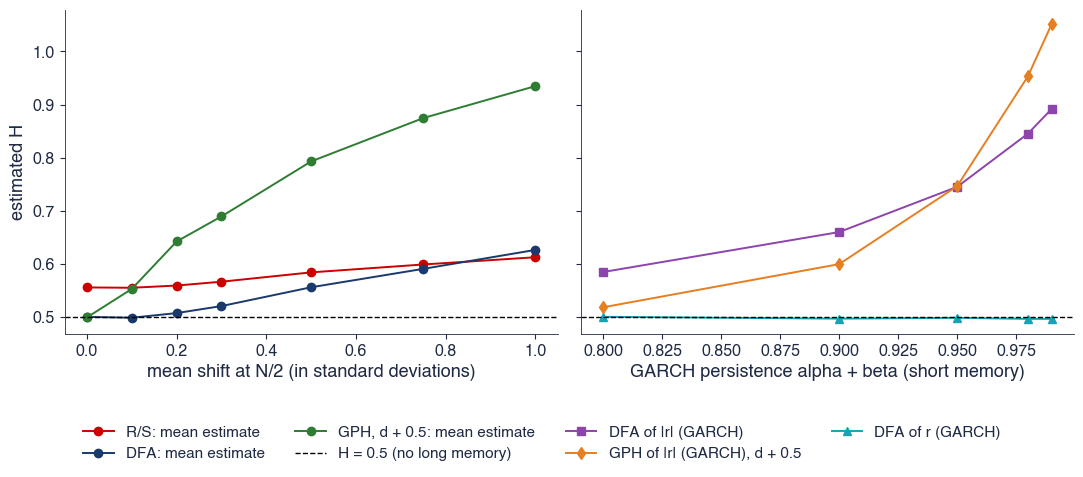

In [24]:
sp = spurious(save=False)
pd.DataFrame(sp['break']).T, pd.DataFrame(sp['garch']).T

## 8. Long memory in volatility on six markets

- ACF of $r_t$, $|r_t|$ and $r_t^2$ (Ding, Granger and Engle, 1993).
- All estimators for $r_t$ and $|r_t|$; the DFA exponent of $|r_t|$ after a random shuffle.

In [25]:
def fig_vol_acf(k='sp500', nlags=250, save=True):
    """ACF of r, |r| and r^2 up to lag 250 (Ding, Granger and Engle 1993)."""
    r = returns(k)
    x = r.values
    fig, ax = plt.subplots(figsize=(10, 4.0))
    lags = np.arange(1, nlags + 1)
    out = {}
    for y, c, nm in [(x, COLORS[k], 'returns r'), (np.abs(x), st.Purple, 'absolute returns |r|'), (x ** 2, st.Orange, 'squared returns r^2')]:
        a = acf(y, nlags)
        ax.plot(lags, a, color=c, lw=1.2, label=nm)
        out[nm.split()[0]] = {'1': float(a[0]), '10': float(a[9]), '50': float(a[49]), '100': float(a[99]), '250': float(a[249]),
                              'npos': int(np.sum(a > 1.96 / np.sqrt(len(x))))}
    band = 1.96 / np.sqrt(len(x))
    ax.axhspan(-band, band, color=st.MainBlue, alpha=0.12, lw=0, label='95% band of an i.i.d. series')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('autocorrelation')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_vol_acf')
    out['band'] = float(band)
    out['n'] = int(len(x))
    rng = np.random.default_rng(SEED + 9)
    out['abs_shuffled_dfa'] = hurst_dfa(rng.permutation(np.abs(x)))
    return out


def markets(names=ASSETS, reps=MC_REPS):
    """All estimators for r and |r| of each series, the i.i.d. Monte Carlo band for its length, DFA of shuffled |r|."""
    out = {}
    for k in names:
        r = returns(k)
        x = r.values
        rng = np.random.default_rng(SEED + 31)
        out[k] = {'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
                  'r': all_estimates(x), 'abs': all_estimates(np.abs(x)), 'mc': mc_null(len(x), reps),
                  'abs_shuffled_dfa': hurst_dfa(rng.permutation(np.abs(x)))}
    return out


def fig_markets(M, save=True):
    """DFA exponents of r and |r| for six series, with the 95% band of i.i.d. series of the same length."""
    fig, ax = plt.subplots(figsize=(10, 4.2))
    names = list(M)
    i = np.arange(len(names))
    for j, k in enumerate(names):
        mc = M[k]['mc']['dfa']
        ax.add_patch(plt.Rectangle((j - 0.3, mc['q025']), 0.6, mc['q975'] - mc['q025'], color=st.MainBlue, alpha=0.15, lw=0,
                                   label='95% band of i.i.d. series of the same length' if j == 0 else '_'))
    ax.plot(i, [M[k]['r']['dfa'] for k in names], 'o', ms=8, color=st.IDAred, label='DFA exponent of returns r')
    ax.plot(i, [M[k]['abs']['dfa'] for k in names], 's', ms=8, color=st.Purple, label='DFA exponent of |r|')
    ax.plot(i, [M[k]['abs_shuffled_dfa'] for k in names], 'x', ms=8, color=st.Forest, label='DFA exponent of |r| after a random shuffle')
    ax.axhline(0.5, color='black', ls='--', lw=1.0, label='H = 0.5')
    ax.set_xticks(i)
    ax.set_xticklabels([NAME[k] for k in names])
    ax.set_ylabel('estimated H')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_markets')

{'returns': {'1': -0.0985804059025294,
  '10': 0.0007234166853708959,
  '50': -0.01875232397570804,
  '100': 0.00414917676937651,
  '250': 0.002646279420943697,
  'npos': 16},
 'absolute': {'1': 0.2891810595149364,
  '10': 0.29543322116077314,
  '50': 0.1271805754039022,
  '100': 0.08221160089876393,
  '250': 0.009331530424877917,
  'npos': 227},
 'squared': {'1': 0.31316071975402004,
  '10': 0.24739943794928934,
  '50': 0.052766846997660016,
  '100': 0.03536522025909547,
  '250': -0.01027231081018586,
  'npos': 128},
 'band': 0.02392023284731494,
 'n': 6714,
 'abs_shuffled_dfa': 0.5105140148835435}

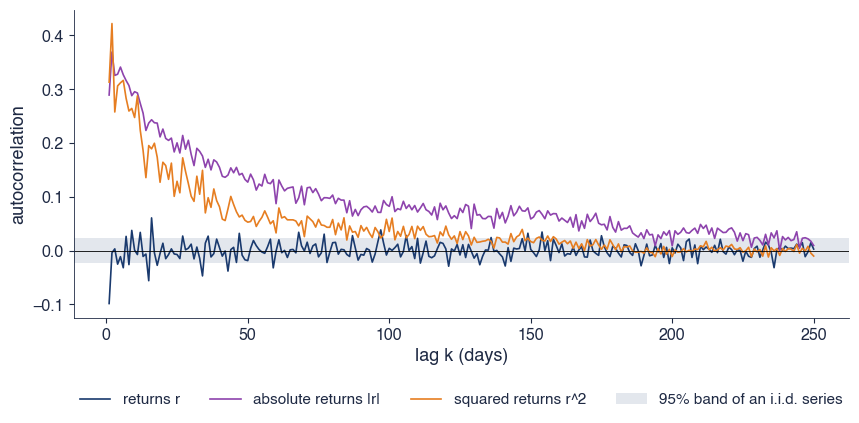

In [26]:
fig_vol_acf(save=False)

,R/S r,DFA r,GPH d r,Lo V r,DFA |r|,GPH d |r|,DFA band 2.5%,DFA band 97.5%,DFA |r| shuffled
S&P 500,0.530,0.488,0.036,1.559,0.953,0.470,0.455,0.540,0.465
DAX,0.550,0.504,-0.059,1.264,0.937,0.480,0.450,0.542,0.476
BET,0.578,0.570,0.166,1.961,0.854,0.467,0.452,0.543,0.494
Bitcoin,0.592,0.561,0.050,1.547,0.820,0.326,0.448,0.549,0.490
Banca Transilvania,0.539,0.473,-0.063,1.071,0.757,0.249,0.447,0.550,0.491
OMV Petrom,0.551,0.490,-0.020,1.524,0.734,0.213,0.446,0.553,0.549


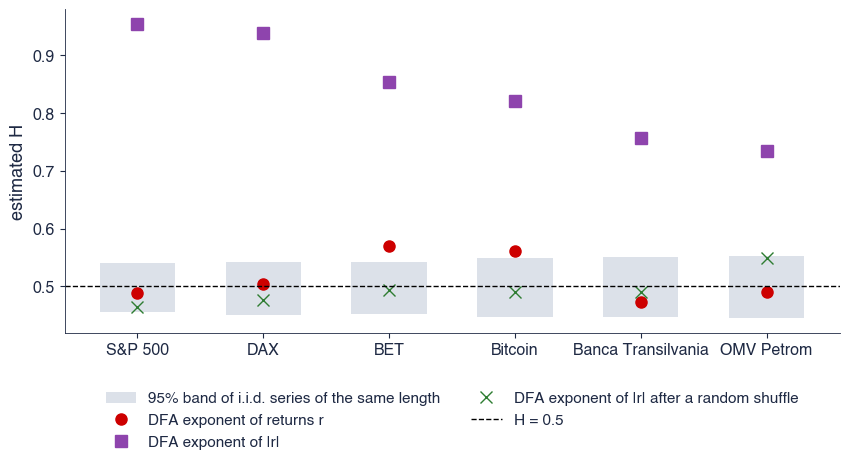

In [27]:
M = markets()
fig_markets(M, save=False)
pd.DataFrame({NAME[k]: {'R/S r': v['r']['rs'], 'DFA r': v['r']['dfa'], 'GPH d r': v['r']['gph_d'], 'Lo V r': v['r']['lo_V'], 'DFA |r|': v['abs']['dfa'], 'GPH d |r|': v['abs']['gph_d'], 'DFA band 2.5%': v['mc']['dfa']['q025'], 'DFA band 97.5%': v['mc']['dfa']['q975'], 'DFA |r| shuffled': v['abs_shuffled_dfa']} for k, v in M.items()}).T.round(3)

## 9. Rolling Hurst exponents

- DFA on windows of 1000 observations moved by 21, dated at the window end; the i.i.d. 95% band for $N = 1000$.

In [28]:
def fig_rolling(names=('sp500', 'bet', 'btc'), save=True, reps=MC_REPS):
    """Rolling DFA exponents of r and |r| (windows of 1000 observations moved by 21), with the i.i.d. 95% band."""
    band = mc_null(WINDOW, reps)['dfa']
    fig, axes = plt.subplots(len(names), 1, figsize=(13, 5.0), sharex=True)
    out = {'band': band}
    for ax, k in zip(axes, names):
        r = returns(k)
        h = rolling_hurst(r)
        ha = rolling_hurst(np.abs(r))
        ax.axhspan(band['q025'], band['q975'], color=st.MainBlue, alpha=0.13, lw=0, label='95% band of i.i.d. series (N = 1000)' if k == names[0] else '_')
        ax.plot(h.index, h.values, color=COLORS[k], lw=1.3, label=f'{NAME[k]}: DFA exponent of r')
        ax.plot(ha.index, ha.values, color=st.Purple, lw=1.0, ls='-', label='DFA exponent of |r|' if k == names[0] else '_')
        ax.axhline(0.5, color='black', ls='--', lw=0.8)
        ax.set_ylabel('H')
        out[k] = {'n_windows': int(len(h)), 'first_end': h.index[0].date().isoformat(), 'last_end': h.index[-1].date().isoformat(),
                  'min': float(h.min()), 'max': float(h.max()), 'date_max': h.idxmax().date().isoformat(),
                  'date_min': h.idxmin().date().isoformat(), 'last': float(h.iloc[-1]),
                  'above': float(np.mean(h > band['q975'])), 'below': float(np.mean(h < band['q025'])),
                  'abs_min': float(ha.min()), 'abs_max': float(ha.max()), 'abs_last': float(ha.iloc[-1]),
                  'first_third': float(h.iloc[:len(h) // 3].mean()), 'last_third': float(h.iloc[-len(h) // 3:].mean())}
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch11_rolling')
    return out

,n_windows,first_end,last_end,min,max,date_max,date_min,last,above,below,abs_min,abs_max,abs_last,first_third,last_third
sp500,273,2003-12-29,2026-09-16,0.315623,0.548681,2021-07-09,2008-12-31,0.427926,0.0,0.238095,0.625441,1.081511,0.802153,0.440693,0.46599
bet,271,2004-01-23,2026-09-18,0.412189,0.622602,2012-10-31,2024-03-06,0.442385,0.199262,0.00369,0.604239,0.985316,0.711158,0.563822,0.515195
btc,162,2017-06-13,2026-09-15,0.452475,0.585502,2020-07-21,2017-09-26,0.548996,0.012346,0.0,0.586058,0.859271,0.693144,0.524512,0.521091


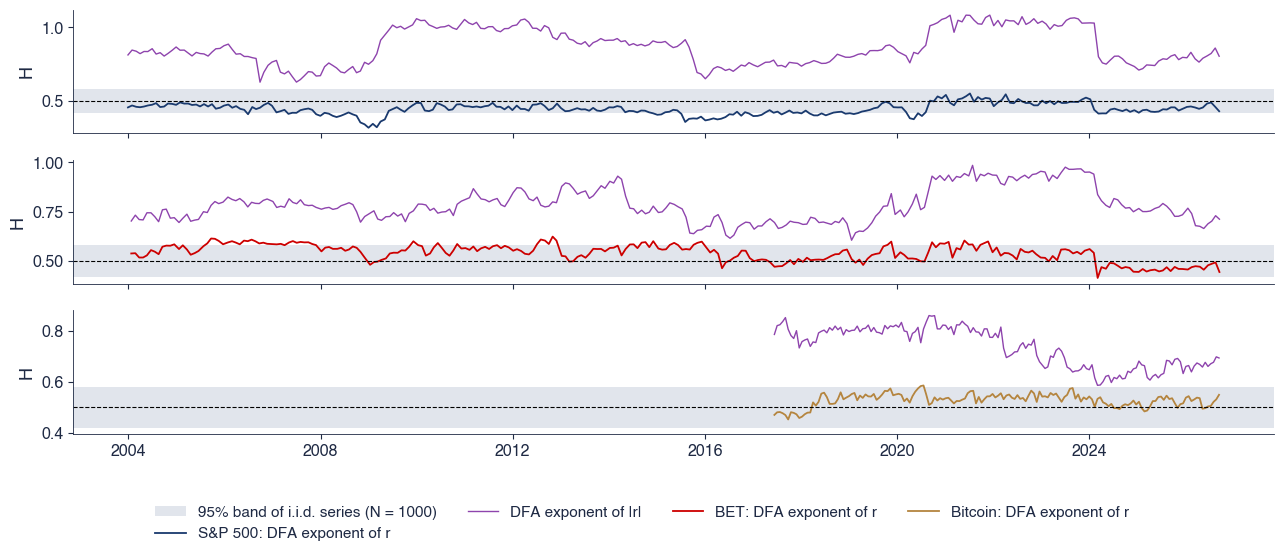

In [29]:
ro = fig_rolling(save=False)
pd.DataFrame({k: v for k, v in ro.items() if k != 'band'}).T

## 10. AI for scientific discovery: does the Hurst exponent change before a crisis?

- Open question: does the rolling exponent of $|r_t|$ rise before crises, or only after them?
- Starter result: rolling DFA of S&P 500 $|r_t|$ on windows of 500 days, around 2008 and 2020.
- Check before trusting any answer, yours or an AI's: dating at the window end, $d = H - 0.5$, a band for each $N$, returns against volatility, the GPH bandwidth.

In [30]:
ra = rolling_hurst(np.abs(returns('sp500')), window=500)
for a, b in [('2007-06-01', '2009-06-30'), ('2019-09-01', '2020-12-31')]:
    print(a, b)
    print(ra.loc[a:b].round(3).to_string())

2007-06-01 2009-06-30
2007-06-07    0.691
2007-07-09    0.673
2007-08-07    0.645
2007-09-06    0.704
2007-10-05    0.716
2007-11-05    0.726
2007-12-05    0.747
2008-01-08    0.722
2008-02-07    0.764
2008-03-10    0.799
2008-04-09    0.697
2008-05-08    0.744
2008-06-09    0.726
2008-07-09    0.709
2008-08-07    0.726
2008-09-08    0.731
2008-10-07    0.745
2008-11-05    0.824
2008-12-05    0.837
2009-01-07    0.934
2009-02-06    0.936
2009-03-10    0.945
2009-04-08    0.987
2009-05-08    0.921
2009-06-09    0.981
2019-09-01 2020-12-31
2019-09-13    0.833
2019-10-14    0.851
2019-11-12    0.879
2019-12-12    0.831
2020-01-14    0.851
2020-02-13    0.876
2020-03-16    0.768
2020-04-15    0.796
2020-05-14    0.926
2020-06-15    1.125
2020-07-15    1.090
2020-08-13    1.125
2020-09-14    1.040
2020-10-13    1.195
2020-11-11    1.102
2020-12-11    1.155
